In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import SM_extractionfunctions

SM_E = SM_extractionfunctions.extract_SMs()

from src.DriftCorrectionFunctions import (
    Drift_Correction_Functions,
    DriftMethod,
    DriftParameters,
    DriftResult,
    CoordinateProcessor

)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

In [3]:
objective_T = S_F.getobjectiveefficiency(wavelength)

In [4]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])

In [5]:
Beads_488_1mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_488_excitation\1mW excitation'
Beads_488_2mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_488_excitation\2mW excitation'
Beads_488_3mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_488_excitation\3mW excitation'
Beads_488_4mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_488_excitation\4mW excitation'
Beads_488_6mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_488_excitation\6mW excitation'
Beads_488_8mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_488_excitation\8mW_excitation'
Beads_488_10mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_488_excitation\10mW_excitation'
#dye_data_folders = np.array([Beads_488_1mw,Beads_488_2mw,Beads_488_3mw,Beads_488_4mw,Beads_488_6mw,Beads_488_8mw,Beads_488_10mw])

Beads_561_1mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_561_excitation\1mW_excitation'
Beads_561_2mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_561_excitation\2mW_excitation'
Beads_561_3mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_561_excitation\3mW_excitation'
Beads_561_4mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_561_excitation\4mW_excitation'
Beads_561_6mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_561_excitation\6mW_excitation'
Beads_561_8mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_561_excitation\8mW_excitation'
Beads_561_10mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_561_excitation\10mW_excitation'
dye_data_folders = np.array([Beads_561_1mw,Beads_561_2mw,Beads_561_3mw,Beads_561_4mw,Beads_561_6mw,Beads_561_8mw,Beads_561_10mw])

Beads_638_1mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_638_excitation\1mW_excitation'
Beads_638_2mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_638_excitation\2mW_excitation'
Beads_638_3mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_638_excitation\3mW_excitation'
Beads_638_4mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_638_excitation\4mW_excitation'
Beads_638_6mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_638_excitation\6mW_excitation'
Beads_638_8mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_638_excitation\8mW_excitation'
Beads_638_10mw = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_638_excitation\10mW_excitation'

#dye_data_folders = np.array([Beads_638_1mw,Beads_638_2mw,Beads_638_3mw,Beads_638_4mw,Beads_638_6mw,Beads_638_8mw,Beads_638_10mw])

In [6]:
example_folder = dye_data_folders[6]
corrected_locs_folder = r'C:\Users\kbhc756\temp_data\BeadCalibrationData\Tetraspeck_638_excitation\1mW_excitation'
localisation_files = H_F.file_search(example_folder, ".h5", "Pos")
localisation_files

array([ 'C:\\Users\\kbhc756\\temp_data\\BeadCalibrationData\\Tetraspeck_561_excitation\\10mW_excitation\\NF_785SP_488LP_10p_561_1_MMStack_16-Pos000_000.h5',
       'C:\\Users\\kbhc756\\temp_data\\BeadCalibrationData\\Tetraspeck_561_excitation\\10mW_excitation\\NF_785SP_488LP_10p_561_1_MMStack_16-Pos000_000_undrifted_locs.h5',
       'C:\\Users\\kbhc756\\temp_data\\BeadCalibrationData\\Tetraspeck_561_excitation\\10mW_excitation\\NF_785SP_488LP_10p_561_1_MMStack_16-Pos000_001.h5',
       'C:\\Users\\kbhc756\\temp_data\\BeadCalibrationData\\Tetraspeck_561_excitation\\10mW_excitation\\NF_785SP_488LP_10p_561_1_MMStack_16-Pos000_001_undrifted_locs.h5',
       'C:\\Users\\kbhc756\\temp_data\\BeadCalibrationData\\Tetraspeck_561_excitation\\10mW_excitation\\NF_785SP_488LP_10p_561_1_MMStack_16-Pos000_002.h5',
       'C:\\Users\\kbhc756\\temp_data\\BeadCalibrationData\\Tetraspeck_561_excitation\\10mW_excitation\\NF_785SP_488LP_10p_561_1_MMStack_16-Pos000_002_undrifted_locs.h5',
       'C:\\Users\

In [7]:
min_cluster_size = 3
chi_val = 2
max_localization_error = 1.5
min_photons = 200
max_photons = 1e6
max_distance = 2

In [8]:
for i in range(localisation_files.size):
    test_locs = pd.read_hdf(localisation_files[i])
    DCF = Drift_Correction_Functions()
    metadata_files = H_F.file_search(example_folder, "metadata", "")
    x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[i])
    n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[i])
    method = 'aim'
    info = [{
        "Width": float(width),
        "Height": float(height),
        "Frames": float(n_frames),
        "Pixelsize": 69.0  # nm per pixel
    }]
    
    params = {
                        "segmentation": 10,  # Larger segments for AIM
                        "intersect_d": 0.1,   # Intersection distance
                        "roi_r": 2.0          # Search radius
                    }
    corrected_locs, drift_result = DCF.undrift(
                    test_locs.to_records(index=False), info, method=method, **params
                )
    corrected_locs = CoordinateProcessor.apply_drift_correction(test_locs,drift_result)
    IO._write_h5_database(corrected_locs, os.path.join(corrected_locs_folder, localisation_files[i].split('.h5')[0] + "_undrifted_locs.h5"), normalise_photons=False)


(615.4359081587652, 616.4359081587652)

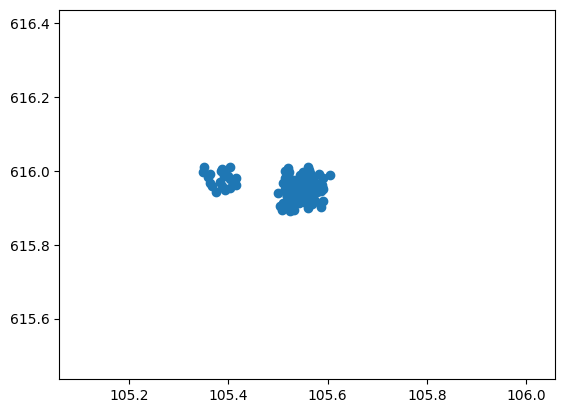

In [9]:
plt.scatter(corrected_locs['xc'],corrected_locs['yc'])
plt.xlim(corrected_locs['xc'][1]-0.5,corrected_locs['xc'][1]+0.5)
plt.ylim(corrected_locs['yc'][1]-0.5,corrected_locs['yc'][1]+0.5)

In [10]:
localisation_files = H_F.file_search(dye_data_folders[6], "_undrifted_locs.h5", "Pos")

9.19304


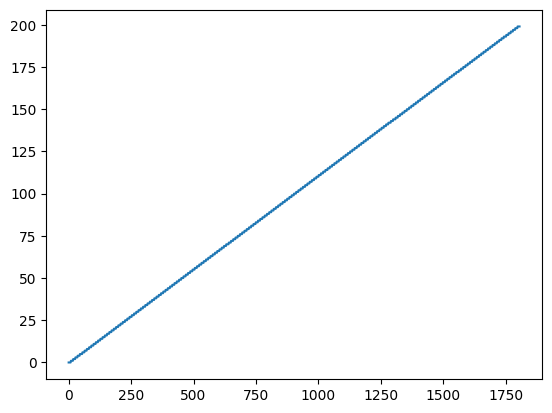

In [11]:
test_locs = pd.read_hdf(localisation_files[8])
print(np.median(test_locs['chi_sqr']))
plt.plot(test_locs['frame'])

In [12]:
localisation_files = H_F.file_search(dye_data_folders[6], "_undrifted_locs.h5", "Pos")
single_frame_database = []
single_molecule_database = []
for i in range(localisation_files.size):
    print(i)
    test_locs = pd.read_hdf(localisation_files[i])
    if test_locs.size>100: #makes sure you have at least 4 localisations
    
        df, loc_data = SM_E.extract_single_molecules_HDBSCAN(
            test_locs,
            min_cluster_size=min_cluster_size,
            max_localization_error=max_localization_error,
            min_photons=min_photons,
            max_photons=max_photons,
        )
        df['stack_index'] = i
        loc_data['stack_index'] = i
        
        if i == 0:
            single_frame_database = loc_data
            single_molecule_database = df
        else:
            single_frame_database = pd.concat([single_frame_database, loc_data])
            single_molecule_database = pd.concat([single_molecule_database, df])

    else:
        df = []
        loc_data = []

IO._write_h5_database(single_frame_database, os.path.join(example_folder,"single_frame_database.h5"), normalise_photons=False)
IO._write_h5_database(single_molecule_database, os.path.join(example_folder,"single_molecule_database.h5"), normalise_photons=False)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


1.6848585679954438
113506.0


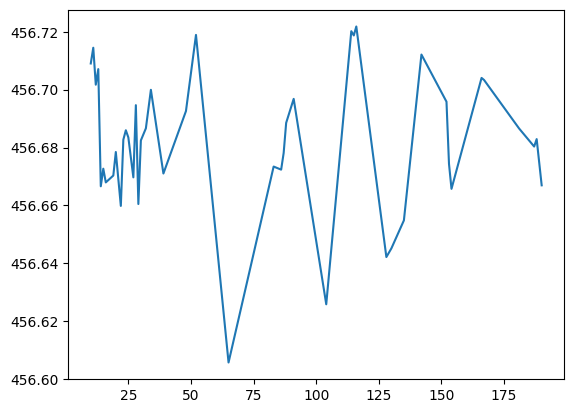

In [13]:
mol = 3
stack = 2
test = single_frame_database[single_frame_database['stack_index']==stack]
test = test[test['molecular_index']==mol]
plt.plot(test['frame'],test['xc'])
print(np.std(test['xc'])*69)
print(np.mean(test['photons']))

In [46]:
single_frame_database_1mw = H_F.file_search(dye_data_folders[0], "single_frame_database.h5", "")
single_molecule_database_1mw = H_F.file_search(dye_data_folders[0], "single_molecule_database.h5", "")

single_frame_database_2mw = H_F.file_search(dye_data_folders[1], "single_frame_database.h5", "")
single_molecule_database_2mw = H_F.file_search(dye_data_folders[1], "single_molecule_database.h5", "")

single_frame_database_3mw = H_F.file_search(dye_data_folders[2], "single_frame_database.h5", "")
single_molecule_database_3mw = H_F.file_search(dye_data_folders[2], "single_molecule_database.h5", "")

single_frame_database_4mw = H_F.file_search(dye_data_folders[3], "single_frame_database.h5", "")
single_molecule_database_4mw = H_F.file_search(dye_data_folders[3], "single_molecule_database.h5", "")

single_frame_database_6mw = H_F.file_search(dye_data_folders[4], "single_frame_database.h5", "")
single_molecule_database_6mw = H_F.file_search(dye_data_folders[4], "single_molecule_database.h5", "")

single_frame_database_8mw = H_F.file_search(dye_data_folders[5], "single_frame_database.h5", "")
single_molecule_database_8mw = H_F.file_search(dye_data_folders[5], "single_molecule_database.h5", "")

single_frame_database_10mw = H_F.file_search(dye_data_folders[6], "single_frame_database.h5", "")
single_molecule_database_10mw = H_F.file_search(dye_data_folders[6], "single_molecule_database.h5", "")

single_frame_database_folders = np.array(
[single_frame_database_1mw,
single_frame_database_2mw,
single_frame_database_3mw,
single_frame_database_4mw,
single_frame_database_6mw,
single_frame_database_8mw,
single_frame_database_10mw
])

single_molecule_database_folders = np.array(
[single_molecule_database_1mw,
single_molecule_database_2mw,
single_molecule_database_3mw,
single_molecule_database_4mw,
single_molecule_database_6mw,
single_molecule_database_8mw,
single_molecule_database_10mw
])

In [8]:
dye_data_folders = np.array(
[Beads_488_1mw,
 Beads_488_2mw,
 Beads_488_3mw,
 Beads_488_4mw,
 Beads_488_6mw,
 Beads_488_8mw,
 Beads_488_10mw,
 Beads_561_1mw,
 Beads_561_2mw,
 Beads_561_3mw,
 Beads_561_4mw,
 Beads_561_6mw,
 Beads_561_8mw,
 Beads_561_10mw,
 Beads_638_1mw,
 Beads_638_2mw,
 Beads_638_3mw,
 Beads_638_4mw,
 Beads_638_6mw,
 Beads_638_8mw,
 Beads_638_10mw])  

In [9]:
mean_photons_all = 0
loc_prec_all = 0
mean_photons_red_all = 0
mean_photons_green_all = 0
mean_photons_blue_all = 0
prec_red_all = 0
prec_green_all = 0
prec_blue_all = 0


for folder_index in range(dye_data_folders.size):

    single_frame_database_file = H_F.file_search(dye_data_folders[folder_index], "single_frame_database.h5", "")
    single_molecule_database_file = H_F.file_search(dye_data_folders[folder_index], "single_molecule_database.h5", "")

    single_frame_database= pd.read_hdf(single_frame_database_file[0])
    single_molecule_database= pd.read_hdf(single_molecule_database_file[0])

    single_molecule_database = single_molecule_database[single_molecule_database['frame']>50]
    
    mean_photons = np.zeros(single_molecule_database['molecular_index'].size)
    loc_prec_x = np.zeros(single_molecule_database['molecular_index'].size)
    loc_prec_y = np.zeros(single_molecule_database['molecular_index'].size)
    loc_prec = np.zeros(single_molecule_database['molecular_index'].size)
    
    mean_red = np.zeros(single_molecule_database['molecular_index'].size)
    mean_green = np.zeros(single_molecule_database['molecular_index'].size)
    mean_blue = np.zeros(single_molecule_database['molecular_index'].size)
    
    prec_red = np.zeros(single_molecule_database['molecular_index'].size)
    prec_green = np.zeros(single_molecule_database['molecular_index'].size)
    prec_blue = np.zeros(single_molecule_database['molecular_index'].size)
    
    mean_photons_red = np.zeros(single_molecule_database['molecular_index'].size)
    mean_photons_green = np.zeros(single_molecule_database['molecular_index'].size)
    mean_photons_blue = np.zeros(single_molecule_database['molecular_index'].size)

    for i in range(single_molecule_database['molecular_index'].size):
        mol = single_molecule_database.molecular_index.iloc[i]
        stack = single_molecule_database.stack_index.iloc[i]
        
        hold = single_frame_database[single_frame_database['stack_index']==stack]
        hold = hold[hold['molecular_index']==mol]
    
        loc_prec_x[i] = np.std(hold['xc'])*69
        loc_prec_y[i] = np.std(hold['yc'])*69
        loc_prec[i] = (loc_prec_x[i] + loc_prec_y[i])/2
    
        mean_photons[i] = np.mean(hold['photons'])
    
        mean_red[i] = np.mean(hold['A_R'])
        mean_green[i] = np.mean(hold['A_G'])
        mean_blue[i] = np.mean(hold['A_B'])
    
        prec_red[i] = np.std(hold['A_R'])/mean_red[i]
        prec_green[i] = np.std(hold['A_G'])/mean_green[i]
        prec_blue[i] = np.std(hold['A_B'])/mean_blue[i]
    
        mean_photons_red[i] = mean_photons[i]*mean_red[i]
        mean_photons_green[i] = mean_photons[i]*mean_green[i]
        mean_photons_blue[i] = mean_photons[i]*mean_blue[i]

    mean_photons_all = np.append(mean_photons,mean_photons_all)
    loc_prec_all = np.append(loc_prec,loc_prec_all)

    mean_photons_red_all = np.append(mean_photons_red,mean_photons_red_all)
    mean_photons_green_all = np.append(mean_photons_green,mean_photons_green_all)
    mean_photons_blue_all = np.append(mean_photons_blue,mean_photons_blue_all)

    prec_red_all = np.append(prec_red,prec_red_all)
    prec_green_all = np.append(prec_green,prec_green_all)
    prec_blue_all = np.append(prec_blue,prec_blue_all)

    
    

mean_color_all = [mean_photons_red_all,mean_photons_green_all,mean_photons_blue_all]
prec_color_all = [prec_red_all,np.multiply(np.sqrt(2),prec_green_all),prec_blue_all]
    

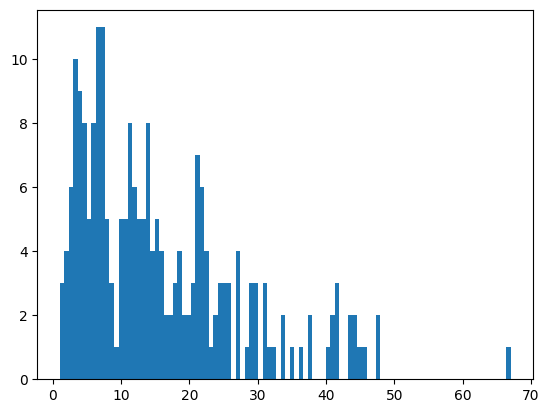

In [23]:
plt.hist(single_molecule_database['background_photons'], 100);
plt.show()

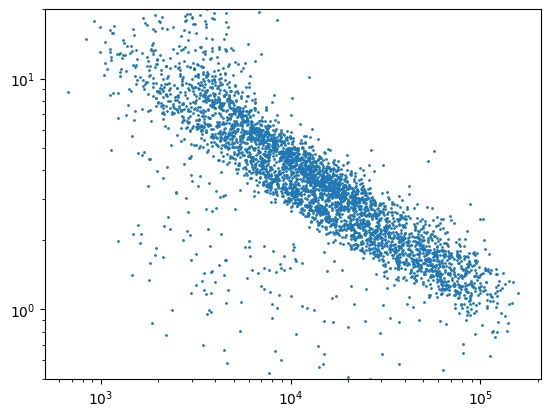

In [9]:
plt.scatter(mean_photons_all,loc_prec_all,s=1)
plt.ylim([0.5,20])
plt.xscale('log')
plt.yscale('log')

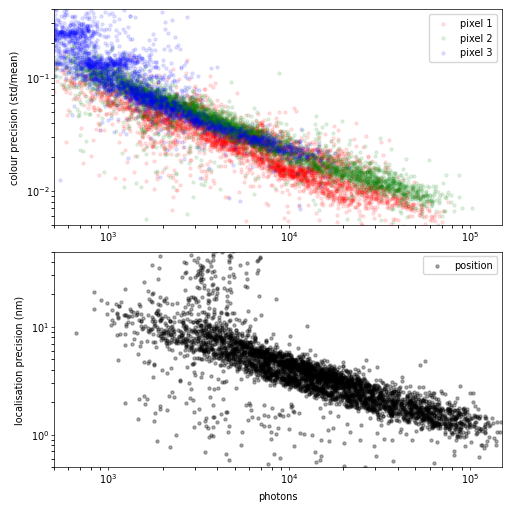

In [10]:

fig, axs = plotter.one_column_plot(
        npanels= 2,
        ratios=[1,1],
        height=5,
        width=5,
    )
ax1 = axs[0]
ax2 = axs[1]

ax1.scatter(mean_photons_red_all,prec_red_all,alpha=0.1,color='r',s=5)
ax1.scatter(mean_photons_green_all,np.sqrt(2)*prec_green_all,alpha=0.1,color='g',s=5)
ax1.scatter(mean_photons_blue_all,prec_blue_all,alpha=0.1,color='b',s=5)
ax1.set_yscale('log')
ax1.set_ylim([0.005,0.4])
ax1.set_xlim([0.5e3,1.5E5])
ax1.set_xscale('log')

ax2.scatter(mean_photons_all,loc_prec_all,alpha=0.3,color='black',s=5)
ax2.set_ylim([0.5,50])
ax2.set_xlim([0.5e3,1.5E5])

plt.yscale('log')
plt.xscale('log')

ax1.set_ylabel('colour precision (std/mean)')
ax2.set_ylabel('localisation precision (nm)')
ax2.set_xlabel('photons')

ax1.legend(['pixel 1','pixel 2','pixel 3'])
ax2.legend(['position'])

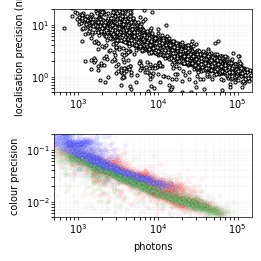

In [11]:
fig, axs = plotter.one_column_plot(
        npanels= 2,
        ratios=[1,1],
        height=2.5,
        width=2.5,
    )
ax1 = axs[0]
ax2 = axs[1]

plotter.scatter_plot(
        ax1,
        mean_photons_all,
        loc_prec_all,
        xlim= [500,1.5e5],
        ylim= [0.5,20],
        label="test",
        edgecolor = "k",
        facecolor = "white",
        s = 5,
        lw = 0.75,
        xaxislabel= " ",
        yaxislabel = "localisation precision (nm)",
        alpha = 1,
        marker= "o",
        rasterized = False,
    )
ax1.set_xscale('log')
ax1.set_yscale('log')


plotter.scatter_plot(
        ax2,
        mean_photons_red_all,
        prec_red_all,
        xlim= [500,1.5e5],
        ylim= [0.005,0.20],
        label="test",
        edgecolor = "r",
        facecolor = "white",
        s = 5,
        lw = 0.75,
        xaxislabel= "x axis",
        yaxislabel = "y axis",
        alpha = 0.06,
        marker= "o",
        rasterized = False,
    )

plotter.scatter_plot(
        ax2,
        mean_photons_green_all,
        np.multiply(np.sqrt(1),prec_green_all),
        xlim= [500,1.5e5],
        ylim= [0.005,0.20],
        label="test",
        edgecolor = "g",
        facecolor = "white",
        s = 5,
        lw = 0.75,
        xaxislabel= "x axis",
        yaxislabel = "y axis",
        alpha = 0.06,
        marker= "o",
        rasterized = False,
    )

plotter.scatter_plot(
        ax2,
        mean_photons_blue_all,
        prec_blue_all,
        xlim= [500,1.5e5],
        ylim= [0.005,0.20],
        label="test",
        edgecolor = "b",
        facecolor = "white",
        s = 5,
        lw = 0.75,
        xaxislabel= "photons",
        yaxislabel = "colour precision",
        alpha = 0.06,
        marker= "o",
        rasterized = False,
    )
ax2.set_xscale('log')
ax2.set_yscale('log')

#fig_savefolder = r'C:\Users\kbhc756\temp_data\BeadCalibrationData'
#plt.savefig(os.path.join(fig_savefolder, 'Precision_Bead_638_excitation.svg'), dpi=600, format='svg')


C:\Users\kbhc756\AppData\Local\Temp\ipykernel_26496\3880593991.py:10: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


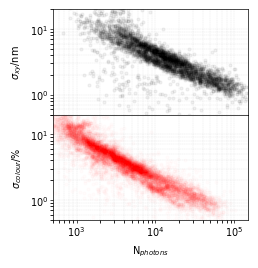

In [12]:
fig, axs = plotter.one_column_plot(
        npanels= 2,
        ratios=[1,1],
        height=2.5,
        width=2.5,
    )
ax1 = axs[0]
ax2 = axs[1]

fig.tight_layout()    
fig.subplots_adjust(hspace=0)                                            

plotter.scatter_plot(
        ax1,
        mean_photons_all,
        loc_prec_all,
        xlim= [500,1.5e5],
        ylim= [0.5,20],
        label="test",
        edgecolor = "k",
        facecolor = "k",
        s = 5,
        lw = 0.75,
        xaxislabel= " ",
        yaxislabel = r"$\sigma_{xy}$/nm",
        alpha = 0.05,
        marker= "o",
        rasterized = True,
    )
ax1.set_xscale('log')
ax1.set_yscale('log')

plotter.scatter_plot(
        ax2,
        mean_color_all,
        np.multiply(100,prec_color_all),
        xlim= [500,1.5e5],
        ylim= [0.5,20],
        label="test",
        edgecolor = "r",
        facecolor = "r",
        s = 5,
        lw = 0.75,
        xaxislabel= r"N$_{photons}$",
        yaxislabel = r"$\sigma_{colour}$/%",
        alpha = 0.01,
        marker= "o",
        rasterized = True,
    )
ax2.set_xscale('log')
ax2.set_yscale('log')

#fig_savefolder = r'C:\Users\kbhc756\temp_data\BeadCalibrationData'
#plt.savefig(os.path.join(fig_savefolder, 'Precision_Beads_all_excitation_scaledGreen.svg'), dpi=600, format='svg')

offset loc =  -0.580634116155


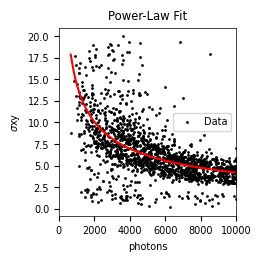

In [13]:

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define the power-law function
def power_law(x, a,c):
    return a * np.power(x, -0.5) + c

loc_prec_all_cleaned_a = loc_prec_all[loc_prec_all > 0.01]
mean_photons_all_cleaned = mean_photons_all[loc_prec_all > 0.01]

loc_prec_all_cleaned = loc_prec_all_cleaned_a[loc_prec_all_cleaned_a < 20]
mean_photons_all_cleaned = mean_photons_all_cleaned[loc_prec_all_cleaned_a < 20]

loc_prec_all_cleaned = loc_prec_all_cleaned[mean_photons_all_cleaned < 2E4]
mean_photons_all_cleaned = mean_photons_all_cleaned[mean_photons_all_cleaned < 2E4]


x_data = mean_photons_all_cleaned
x_data = x_data[~np.isnan(x_data)]
sorted_indices = np.argsort(x_data)
x_data_loc = x_data[sorted_indices]


y_data = loc_prec_all_cleaned
y_data = y_data[~np.isnan(y_data)]
y_data_loc = y_data[sorted_indices]

weights = 1 / x_data_loc#(np.random.normal(np.mean(x_data), np.std(x_data), size=x_data.size))  # Example weights

# Fit the power-law model to the data
params, covariance = curve_fit(power_law, x_data_loc, y_data_loc,sigma=weights,absolute_sigma=True)
# Extract fitted parameters
a_fit_loc,offset_loc = params

# Plot the data and the fitted curve
plt.scatter(x_data_loc, y_data_loc, label="Data", color="black",alpha=1,s=1)
plt.plot(x_data_loc, power_law(x_data_loc, a_fit_loc,offset_loc),color="red")
plt.xlabel("photons")
plt.ylabel("$\sigma$xy")
plt.legend()
plt.title("Power-Law Fit")
plt.xscale('linear')
plt.yscale('linear')
plt.xlim([0,1E4])
print('offset loc = ',str(offset_loc))

offset color =  -1.13562382855


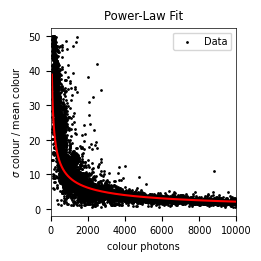

In [14]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define the power-law function
def power_law(x, a,c):
    return a * np.power(x, -0.5) + c

prec_color_all_scaled = np.multiply(prec_color_all,100)
mean_color_all_stack = np.stack(mean_color_all)

prec_color_all_cleaned_a = prec_color_all_scaled[prec_color_all_scaled > 0.5]
mean_color_all_cleaned = mean_color_all_stack[prec_color_all_scaled > 0.5]

prec_color_all_cleaned = prec_color_all_cleaned_a[prec_color_all_cleaned_a < 50]
mean_color_all_cleaned = mean_color_all_cleaned[prec_color_all_cleaned_a < 50]

prec_color_all_cleaned = prec_color_all_cleaned[mean_color_all_cleaned < 2E4]
mean_color_all_cleaned = mean_color_all_cleaned[mean_color_all_cleaned < 2E4]


x_data = mean_color_all_cleaned
x_data = x_data[~np.isnan(x_data)]
sorted_indices = np.argsort(x_data)
x_data_color = x_data[sorted_indices]


y_data = prec_color_all_cleaned
y_data = y_data[~np.isnan(y_data)]
y_data_color = y_data[sorted_indices]

weights = 1 / x_data_color#(np.random.normal(np.mean(x_data), np.std(x_data), size=x_data.size))  # Example weights

# Fit the power-law model to the data
params, covariance = curve_fit(power_law, x_data_color, y_data_color,sigma=weights,absolute_sigma=True)
# Extract fitted parameters
a_fit_color,offset_color = params

# Plot the data and the fitted curve
plt.scatter(x_data_color, y_data_color, label="Data", color="black",alpha=1,s=1)
plt.plot(x_data_color, power_law(x_data_color, a_fit_color,offset_color),color="red")
plt.xlabel("colour photons")
plt.ylabel("$\sigma$ colour / mean colour")
plt.legend()
plt.title("Power-Law Fit")
plt.xscale('linear')
plt.yscale('linear')
plt.xlim([0,1E4])
print('offset color = ',str(offset_color))

In [24]:
power_law(22000,a_fit_color,offset_color)

1.0665820805099542

In [15]:
x_data.size

10656

C:\Users\kbhc756\AppData\Local\Temp\ipykernel_26496\3841450571.py:12: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


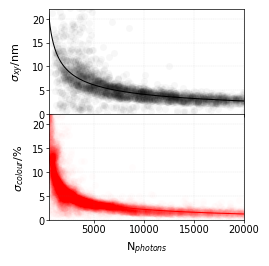

In [20]:
x_data = np.logspace(2,6,1000)

fig, axs = plotter.one_column_plot(
        npanels= 2,
        ratios=[1,1],
        height=2.5,
        width=2.5,
    )
ax1 = axs[0]
ax2 = axs[1]

fig.tight_layout()    
fig.subplots_adjust(hspace=0)                                            

plotter.scatter_plot(
        ax1,
        mean_photons_all,
        loc_prec_all,
        xlim= [0,2e4],
        ylim= [0,20],
        label="test",
        edgecolor = "k",
        facecolor = "k",
        s = 100,
        lw = 0.0,
        xaxislabel= " ",
        yaxislabel = r"$\sigma_{xy}$/nm",
        alpha = 0.03,
        marker= ".",
        rasterized = True,
    )
ax1.set_xscale('linear')
ax1.set_yscale('linear')

plotter.scatter_plot(
        ax2,
        mean_color_all,
        np.multiply(100,prec_color_all),
        xlim= [0,2e4],
        ylim= [0,20],
        label="test",
        edgecolor = "r",
        facecolor = "r",
        s = 100,
        lw = 0.0,
        xaxislabel= r"N$_{photons}$",
        yaxislabel = r"$\sigma_{colour}$/%",
        alpha = 0.01,
        marker= ".",
        rasterized = True,
    )
ax2.set_xscale('linear')
ax2.set_yscale('linear')


plotter.line_plot(
        ax1,
        x = x_data,
        y = power_law(x_data, a_fit_loc,offset_loc),
        xlim= [500,2e4],
        ylim= [0,22],
        color ="k",
        lw = 0.75,
        label = "",
        xaxislabel= " ",
        yaxislabel = r"$\sigma_{xy}$/nm",
        ls="-",
        alpha= 1)

plotter.line_plot(
        ax2,
        x = x_data,
        y = power_law(x_data, a_fit_color,offset_color),
        xlim= [500,2e4],
        ylim= [0,22],
        color ="r",
        lw = 0.75,
        label = "",
        xaxislabel= r"N$_{photons}$",
        yaxislabel = r"$\sigma_{colour}$/%",
        ls="-",
        alpha= 1)
ax1.set_xticklabels([])
fig_savefolder = r'C:\Users\kbhc756\temp_data\BeadCalibrationData'
plt.savefig(os.path.join(fig_savefolder, 'Precision_Beads_all_excitation_scaledGreen_powerLawFitsLinear.svg'), dpi=600, format='svg')
    